In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u 
import astropy.io.fits as fits

In [3]:
import sys

sys.path.append('/Users/jhchen/work/projects/code_snippets/utils')
sys.path.append('/Users/jhchen/work/projects/code_snippets/tasks')

In [4]:
from image_utils import Image, image_resample
from modeling_utils import Sersic2D, Parameter, Model, Grid2D
from galaxyfit import fit_galaxy_with_psf
from galaxyfit import Ferrers2D
from astropy.convolution import convolve

In [5]:
datadir = '/Users/jhchen/work/data/tests/JWST/G4_38232/'

# Data

In [6]:
# G4_38232
name = 'G4_38232'
z = 1.11594
stellar_Re = 4.374 #kpc
stellar_Re_arcsec = 0.534 

In [7]:
# F444W
stellar_f444w_file = datadir + 'G4_38232_JWST_NIRCAM_F444W_cutout_6.0_arcsec.DZL.fits'
stellar_f444w_err_file = datadir + 'ERR/G4_38232_JWST_NIRCAM_F444W_cutout_6.0_arcsec.DZL_ERR.fits'
stellar_f444w_psf_file = datadir + 'PSF/G4_38232_NIRCam_F444W-CLEAR_combinedModelPSF.fits'

stellar_f444w_image = Image()
stellar_f444w_err = Image()
stellar_f444w_psf = Image()
stellar_f444w_image.readfits(stellar_f444w_file)
stellar_f444w_err.readfits(stellar_f444w_err_file)
stellar_f444w_psf.readfits(stellar_f444w_psf_file)

# resample the PSF to a much smaller cutout, only the central part matters most
print("image shape",stellar_f444w_image.shape)
print("psf shape",stellar_f444w_psf.shape)

stellar_f444w_PSF_resampled = image_resample(stellar_f444w_psf.data, pixel_size_in=stellar_f444w_psf.header['PIXELSCL'], 
                               pixel_size_out=stellar_f444w_image.pixel_sizes.value[0], 
                               shape_out=(101,101))
#plt.imshow(stellar_f444w_PSF_resampled, vmax=0.0002)

image shape (240, 240)
psf shape (800, 800)


In [8]:
stellar_f356w_file = datadir + 'G4_38232_JWST_NIRCAM_F356W_cutout_6.0_arcsec.DZL.fits'
stellar_f356w_err_file = datadir + 'ERR/G4_38232_JWST_NIRCAM_F356W_cutout_6.0_arcsec.DZL_ERR.fits'
stellar_f356w_psf_file = datadir + 'PSF/G4_38232_NIRCam_F356W-CLEAR_combinedModelPSF.fits'
stellar_f356w_image = Image()
stellar_f356w_err = Image()
stellar_f356w_psf = Image()
stellar_f356w_image.readfits(stellar_f356w_file)
stellar_f356w_err.readfits(stellar_f356w_err_file)
stellar_f356w_psf.readfits(stellar_f356w_psf_file)

# resample the PSF to a much smaller cutout, only the central part matters most
print("image shape",stellar_f356w_image.shape)
print("psf shape",stellar_f356w_psf.shape)

stellar_f356w_PSF_resampled = image_resample(stellar_f356w_psf.data, pixel_size_in=stellar_f356w_psf.header['PIXELSCL'], 
                               pixel_size_out=stellar_f356w_image.pixel_sizes.value[0], 
                               shape_out=(101,101))                               
#plt.imshow(stellar_f356w_PSF_resampled, vmax=0.0002)

cut_s = np.s_[59:159,73:173]

stellar_f356w_image_cut = stellar_f356w_image.data[cut_s]
stellar_f356w_err_cut = stellar_f356w_err.data[cut_s]

image shape (240, 240)
psf shape (800, 800)


In [9]:
stellar_f277w_file = datadir + 'G4_38232_JWST_NIRCAM_F277W_cutout_6.0_arcsec.DZL.fits'
stellar_f277w_err_file = datadir + 'ERR/G4_38232_JWST_NIRCAM_F277W_cutout_6.0_arcsec.DZL_ERR.fits'
stellar_f277w_psf_file = datadir + 'PSF/G4_38232_NIRCam_F277W-CLEAR_combinedModelPSF.fits'
stellar_f277w_image = Image()
stellar_f277w_err = Image()
stellar_f277w_psf = Image()
stellar_f277w_image.readfits(stellar_f277w_file)
stellar_f277w_err.readfits(stellar_f277w_err_file)
stellar_f277w_psf.readfits(stellar_f277w_psf_file)

# resample the PSF to a much smaller cutout, only the central part matters most
print("image shape",stellar_f277w_image.shape)
print("psf shape",stellar_f277w_psf.shape)

stellar_f277w_PSF_resampled = image_resample(stellar_f277w_psf.data, pixel_size_in=stellar_f277w_psf.header['PIXELSCL'], 
                               pixel_size_out=stellar_f277w_image.pixel_sizes.value[0], 
                               shape_out=(101,101))                               
#plt.imshow(stellar_f227w_PSF_resampled, vmax=0.0002)

cut_s = np.s_[59:159,73:173]

stellar_f277w_image_cut = stellar_f277w_image.data[cut_s]
stellar_f277w_err_cut = stellar_f277w_err.data[cut_s]

image shape (240, 240)
psf shape (800, 800)


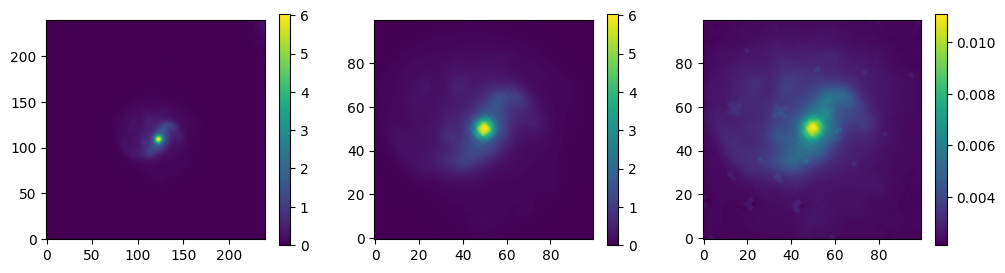

In [10]:
cut_s = np.s_[59:159,73:173]

stellar_f444w_image_cut = stellar_f444w_image.data[cut_s]
stellar_f444w_err_cut = stellar_f444w_err.data[cut_s]

fig, ax = plt.subplots(1,3, figsize=(12,3))
im=ax[0].imshow(stellar_f444w_image.data, origin='lower'); plt.colorbar(im, ax=ax[0])
im=ax[1].imshow(stellar_f444w_image_cut, origin='lower'); plt.colorbar(im, ax=ax[1])
im=ax[2].imshow(stellar_f444w_err_cut, origin='lower'); plt.colorbar(im, ax=ax[2])


{'x0': 0.3608621917465002, 'y0': 0.3681712224555708}
[122.8608621917465, 108.86817122245557]


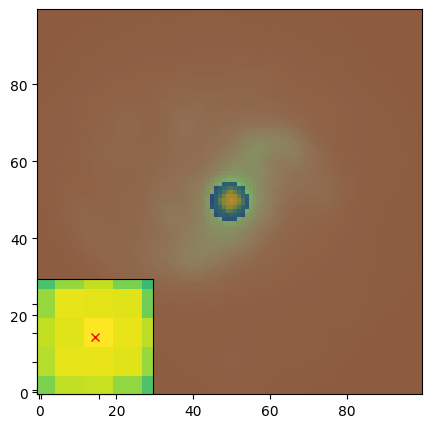

In [11]:
# manually get the center of the galaxy

from galaxyfit import fit_galaxy_center

fixed_center_params = fit_galaxy_center(stellar_f444w_image_cut, radius=5)
x0, y0 = fixed_center_params['x0'], fixed_center_params['y0']
center_ori = [x0 + cut_s[1].start + 0.5*(cut_s[1].stop-cut_s[1].start)-0.5, 
          y0 + cut_s[0].start + 0.5*(cut_s[0].stop-cut_s[0].start)-0.5]
print(fixed_center_params)
print(center_ori)

# Fitting 

## Fit Bulge+Disk

Initial guess: {'bulge.amplitude': 5, 'bulge.reff': 3, 'bulge.n': 3, 'bulge.ellip': 0, 'bulge.theta': 0, 'disk.amplitude': 0.7, 'disk.reff': 20, 'disk.n': 1}


/Users/jhchen/work/projects/code_snippets/utils/modeling_utils.py:939: RuntimeWarning: divide by zero encountered in divide
  r = np.sqrt((x_maj / reff) ** 2 + (x_min / b) ** 2)


Parameters: ['bulge.amplitude', 'bulge.reff', 'bulge.n', 'bulge.ellip', 'bulge.theta', 'disk.amplitude', 'disk.reff', 'disk.n']
First best-fit: [ 1.72000281  9.36974216  2.67531888  0.64242274  0.9436596   0.29757983
 23.7185734   0.55950342]
data_size=10000; chi2=5.801e+06; reduced_chi2=580.6
`ftol` termination condition is satisfied.
Function evaluations 20, initial cost 1.6357e+05, final cost 1.5801e+05, first-order optimality 1.43e+00.
n_data_resid=10000; n_prior_resid=0
chi2_data=6.023e+06; dof=9992; reduced_chi2=602.8
Parameter errors: [0.73804916 0.82147859 0.53342019 0.07432024 0.04698358 0.03227827
 1.03503612 0.0900336 ]
bulge.amplitude, 2.668+/-0.738
bulge.reff, 7.096+/-0.821
bulge.n, 2.119+/-0.533
bulge.ellip, 0.617+/-0.074
bulge.theta, 0.988+/-0.047
disk.amplitude, 0.346+/-0.032
disk.reff, 22.774+/-1.035
disk.n, 0.535+/-0.090
Bulge to Total (B/T) 0.3727875170057941


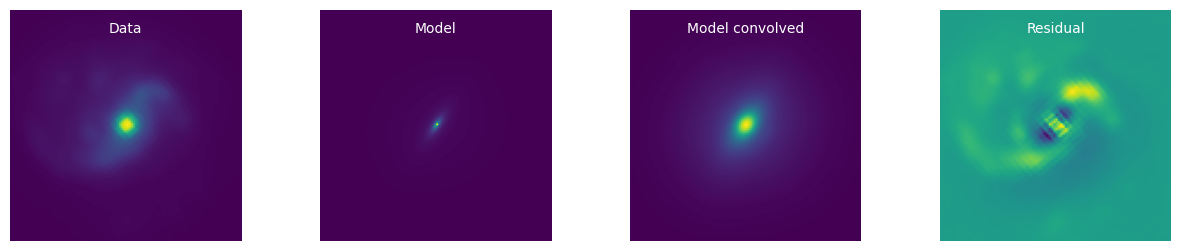

In [16]:
# Test-1
# Model = Bulge + Disk, fixed center, fixed geometry

#  common parameters
x0, y0 = center_ori
b2a = 0.887
theta = -2.705
stellar_image_cut = stellar_f444w_image_cut
stellar_err_cut = stellar_f444w_err_cut
stellar_psf = stellar_f444w_PSF_resampled
outfile = f'result_data/{name}_bulgedisk_fit_f444w.fits'


#fixed_parameters={'theta.disk': theta, 'ellip.disk':1-b2a, **fixed_center_params},
fixed_parameters={'disk.theta': theta, 'disk.ellip':1-b2a,
                  #'bulge.n':4, 'bulge.reff':5,
                  'bulge.x0':fixed_center_params['x0'], 
                  'bulge.y0':fixed_center_params['y0'], 
                  }

bulge = Sersic2D(
        amplitude=5, reff=3, n=3,
        x0=x0, y0=y0, ellip=0, theta=0,
        name='bulge')
bulge.set_bounds({
        'amplitude': (0.1, 20), 'reff': (0., 20), 'n': (0.2, 6),
    })

disk = Sersic2D(
       amplitude=0.7, reff=20, n=1,
       x0=x0, y0=y0, ellip=0, theta=0,
       name='disk')
disk.set_bounds({
        'amplitude': (0.01, 5), 'reff': (10, 50), 'n': (0.1, 4),
    })

model_galaxy = bulge + disk # disk+bulge
model_galaxy.tie('bulge.x0', 'disk.x0')
model_galaxy.tie('bulge.y0', 'disk.y0')
model_galaxy.fix(**fixed_parameters)

bestfit, *_ = fit_galaxy_with_psf(
    model_galaxy, stellar_image_cut,
    error=stellar_err_cut,
    psf=stellar_psf, #mode='de',
    return_fit_images=True, debug=True, #mask=mask1,
    fitsfile=outfile)
for item, value, value_err in zip(bestfit.keys, bestfit.best_fit, 
    bestfit.best_fit_error):
    print(f'{item}, {value:.3f}+/-{value_err:.3f}')

grid2d = Grid2D(size=stellar_image_cut.shape)
bulge.update_parameters(bestfit.parameters)
disk.update_parameters(bestfit.parameters)
bulge_model_fitted = bulge(grid2d)
disk_model_fitted = disk(grid2d)
B2T = np.sum(bulge_model_fitted)/np.sum(bulge_model_fitted + disk_model_fitted)
print('Bulge to Total (B/T)', B2T)

## Fit Bar+Disk

Initial guess: {'bar.amplitude': 5, 'bar.a_bar': 10, 'bar.n': 1, 'bar.ellip': 0, 'bar.theta': 0, 'bar.c': 0, 'disk.amplitude': 0.7, 'disk.reff': 20, 'disk.n': 1}


/Users/jhchen/work/projects/code_snippets/tasks/galaxyfit.py:1204: RuntimeWarning: divide by zero encountered in scalar divide
  inv_expon = 1.0 / expon
/Users/jhchen/work/projects/code_snippets/tasks/galaxyfit.py:1205: RuntimeWarning: divide by zero encountered in divide
  r = (np.abs(x_maj / a_bar) ** expon +
/Users/jhchen/work/projects/code_snippets/tasks/galaxyfit.py:1206: RuntimeWarning: divide by zero encountered in divide
  np.abs(x_min / b_bar) ** expon) ** inv_expon
/Users/jhchen/work/projects/code_snippets/tasks/galaxyfit.py:1205: RuntimeWarning: overflow encountered in power
  r = (np.abs(x_maj / a_bar) ** expon +


Parameters: ['bar.amplitude', 'bar.a_bar', 'bar.n', 'bar.ellip', 'bar.theta', 'bar.c', 'disk.amplitude', 'disk.reff', 'disk.n']
First best-fit: [16.49746064  9.4941125   0.5         0.53003236  1.09997106 -1.30790325
  0.43039435 21.48241971  0.88712742]
data_size=10000; chi2=7.577e+06; reduced_chi2=758.4
`xtol` termination condition is satisfied.
Function evaluations 27, initial cost 1.7311e+05, final cost 1.6865e+05, first-order optimality 2.56e+04.
n_data_resid=10000; n_prior_resid=0
chi2_data=7.472e+06; dof=9991; reduced_chi2=747.9
Parameter errors: [12.50146839 15.764742    3.46656483  0.16988359  0.04586336  0.30160752
  0.03678489  0.86645717  0.10428942]
bar.amplitude, 16.211+/-12.501
bar.a_bar, 13.943+/-15.765
bar.n, 0.500+/-3.467
bar.ellip, 0.535+/-0.170
bar.theta, 1.150+/-0.046
bar.c, -1.493+/-0.302
disk.amplitude, 0.440+/-0.037
disk.reff, 21.149+/-0.866
disk.n, 0.707+/-0.104
Bar to Total (Bar/T) 0.22413034718349356


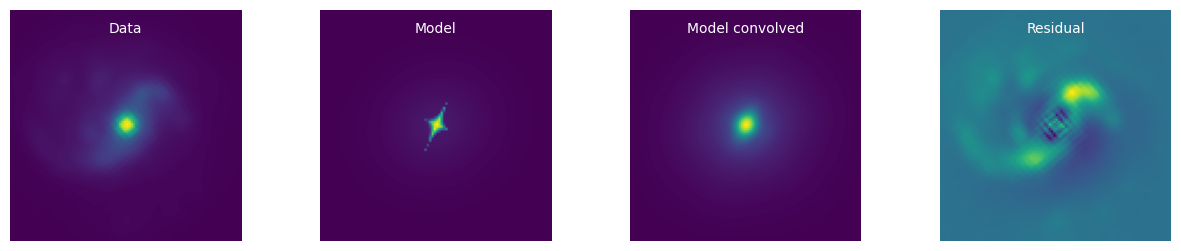

In [ ]:
# Test-2
# Model = Bar + Disk, fixed center, fixed geometry


#  common parameters
x0, y0 = center_ori
b2a = 0.887
theta = -2.705
stellar_image_cut = stellar_f444w_image_cut
stellar_err_cut = stellar_f444w_err_cut
stellar_psf = stellar_f444w_PSF_resampled
outfile = f'result_data/{name}_barreddisk_fit_f444w.fits'


fixed_parameters={'disk.theta': theta, 'disk.ellip':1-b2a,
                  #'bulge.n':4, 'bulge.reff':5,
                  'bar.x0':fixed_center_params['x0'], 
                  'bar.y0':fixed_center_params['y0'], 
                  }

bar = Ferrers2D(
        amplitude=5, a_bar=10, n=1,
        x0=x0, y0=y0, ellip=0, theta=0, c=0,
        name='bar')
bar.set_bounds({
        'amplitude': (0.1, 20), 'a_bar': (0., 40), 'n': (0.5, 4),
        'ellip':(0.4,0.8)
    })

disk = Sersic2D(
       amplitude=0.7, reff=20, n=1,
       x0=x0, y0=y0, ellip=0, theta=0,
       name='disk')
disk.set_bounds({
        'amplitude': (0.01, 5), 'reff': (10, 50), 'n': (0.1, 4),
    })

model_barred_disk = bar + disk # disk+bulge
model_barred_disk.tie('bulge.x0', 'bar.x0', 'disk.x0')
model_barred_disk.tie('bulge.y0', 'bar.y0', 'disk.y0')
model_barred_disk.fix(**fixed_parameters)

bestfit, *_ = fit_galaxy_with_psf(
    model_barred_disk, stellar_image_cut,
    error=stellar_err_cut,
    psf=stellar_psf, #mode='de',
    return_fit_images=True, debug=True, #mask=mask1,
    fitsfile=outfile)
for item, value, value_err in zip(bestfit.keys, bestfit.best_fit, 
    bestfit.best_fit_error):
    print(f'{item}, {value:.3f}+/-{value_err:.3f}')

grid2d = Grid2D(size=stellar_image_cut.shape)
bar.update_parameters(bestfit.parameters)
disk.update_parameters(bestfit.parameters)
bar_model_fitted = bar(grid2d)
disk_model_fitted = disk(grid2d)
Bar2T = np.sum(bar_model_fitted)/np.sum(bar_model_fitted + disk_model_fitted)
print('Bar to Total (Bar/T)', Bar2T)

## Fit Bulge+Bar+Disk

Initial guess: {'bulge.amplitude': 5, 'bulge.reff': 3, 'bulge.n': 3, 'bulge.x0': 122.8608621917465, 'bulge.y0': 108.86817122245557, 'bar.amplitude': 1, 'bar.a_bar': 10, 'bar.ellip': 0, 'bar.theta': 0, 'disk.amplitude': 0.7, 'disk.reff': 20}


/Users/jhchen/work/projects/code_snippets/utils/modeling_utils.py:939: RuntimeWarning: divide by zero encountered in divide
  r = np.sqrt((x_maj / reff) ** 2 + (x_min / b) ** 2)


Parameters: ['bulge.amplitude', 'bulge.reff', 'bulge.n', 'bulge.x0', 'bulge.y0', 'bar.amplitude', 'bar.a_bar', 'bar.ellip', 'bar.theta', 'disk.amplitude', 'disk.reff']
First best-fit: [1.00000000e-01 0.00000000e+00 2.00000000e-01 1.26163069e+02
 1.12170378e+02 2.00000000e+01 7.01109475e+00 5.49259847e-01
 1.15954849e+00 4.36659807e-01 2.11057833e+01]
data_size=10000; chi2=7.655e+06; reduced_chi2=766.3
`xtol` termination condition is satisfied.
Function evaluations 4, initial cost 1.7439e+05, final cost 1.7249e+05, first-order optimality 1.68e+04.
n_data_resid=10000; n_prior_resid=0
chi2_data=7.757e+06; dof=9989; reduced_chi2=776.5
Parameter errors: [0.00000000e+00 2.18559155e-13 2.40067735e-14 4.46581156e-15
 4.07507082e-15 9.78126554e+00 1.35053737e+00 1.95412027e-01
 2.31783168e-01 4.06798022e-02 7.71118800e-01]
bulge.amplitude, 19.938+/-0.000
bulge.reff, 9.969+/-0.000
bulge.n, 5.982+/-0.000
bulge.x0, 1310952.705+/-0.000
bulge.y0, 226907.769+/-0.000
bar.amplitude, 20.000+/-9.781
bar.

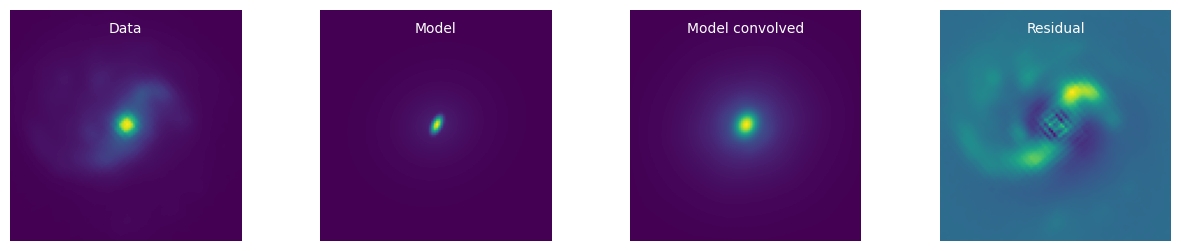

In [ ]:
# Test-3
# Model = Bar + Disk, fixed center, fixed geometry


#  common parameters
x0, y0 = center_ori
b2a = 0.887
theta = -2.705
stellar_image_cut = stellar_f444w_image_cut
stellar_err_cut = stellar_f444w_err_cut
stellar_psf = stellar_f444w_PSF_resampled
outfile = f'result_data/{name}_bulgebardisk_fit_f444w.fits'


fixed_parameters={'disk.theta': theta, 'disk.ellip':1-b2a,
                  'bulge.ellip':0, 'bulge.theta':0,
                  'bar.x0':fixed_center_params['x0'], 
                  'bar.y0':fixed_center_params['y0'], 
                  'bar.c':0, 'bar.n':2,
                  'disk.n':1,
                  }

bulge = Sersic2D(
        amplitude=5, reff=3, n=3,
        x0=x0, y0=y0, ellip=0, theta=0,
        name='bulge')
bulge.set_bounds({
        'amplitude': (0.1, 20), 'reff': (0., 10), 'n': (0.2, 6),
    })

bar = Ferrers2D(
        amplitude=1, a_bar=10, n=1,
        x0=x0, y0=y0, ellip=0, theta=0, c=0,
        name='bar')
bar.set_bounds({
        'amplitude': (0.1, 20), 'a_bar': (0., 40), 'n': (0.5, 4),
        'ellip':(0.4,0.8)
    })

disk = Sersic2D(
       amplitude=0.7, reff=20, n=1,
       x0=x0, y0=y0, ellip=0, theta=0,
       name='disk')
disk.set_bounds({
        'amplitude': (0.01, 5), 'reff': (10, 50), 'n': (0.1, 4),
    })

model_bulge_bar_disk = bulge + bar + disk # disk+bulge
model_bulge_bar_disk.tie('bar.x0', 'disk.x0')
model_bulge_bar_disk.tie('bar.y0', 'disk.y0')
model_bulge_bar_disk.fix(**fixed_parameters)

bestfit, *_ = fit_galaxy_with_psf(
    model_bulge_bar_disk, stellar_image_cut,
    error=stellar_err_cut,
    psf=stellar_psf, #mode='de',
    return_fit_images=True, debug=True, #mask=mask1,
    fitsfile=outfile)
for item, value, value_err in zip(bestfit.keys, bestfit.best_fit, 
    bestfit.best_fit_error):
    print(f'{item}, {value:.3f}+/-{value_err:.3f}')

grid2d = Grid2D(size=stellar_image_cut.shape)
bar.update_parameters(bestfit.parameters)
disk.update_parameters(bestfit.parameters)
bulge_model_fitted = bulge(grid2d)
bar_model_fitted = bar(grid2d)
disk_model_fitted = disk(grid2d)
B2T = np.sum(bulge_model_fitted)/np.sum(bulge_model_fitted + bar_model_fitted + disk_model_fitted)
print('Bar to Total (B/T)', B2T)

# F277W

{'x0': 0.2616688034253005, 'y0': 0.3398017114942945}
[122.7616688034253, 108.83980171149429]


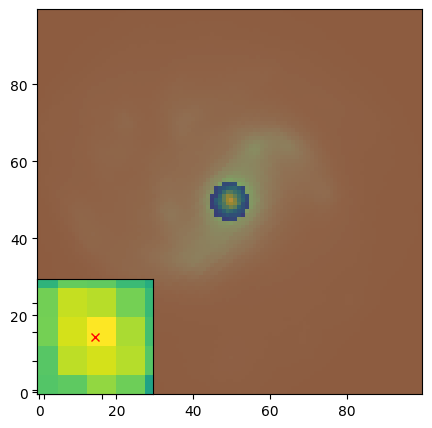

In [15]:
# manually get the center of the galaxy

from galaxyfit import fit_galaxy_center

fixed_center_params = fit_galaxy_center(stellar_f277w_image_cut, radius=5)
x0, y0 = fixed_center_params['x0'], fixed_center_params['y0']
center_ori = [x0 + cut_s[1].start + 0.5*(cut_s[1].stop-cut_s[1].start)-0.5, 
          y0 + cut_s[0].start + 0.5*(cut_s[0].stop-cut_s[0].start)-0.5]
print(fixed_center_params)
print(center_ori)

## Bulge+Disk

Initial guess: {'bulge.amplitude': 5, 'bulge.reff': 3, 'bulge.n': 3, 'bulge.ellip': 0, 'bulge.theta': 0, 'disk.amplitude': 0.7, 'disk.reff': 20, 'disk.n': 1}


/Users/jhchen/work/projects/code_snippets/utils/modeling_utils.py:939: RuntimeWarning: divide by zero encountered in divide
  r = np.sqrt((x_maj / reff) ** 2 + (x_min / b) ** 2)


Parameters: ['bulge.amplitude', 'bulge.reff', 'bulge.n', 'bulge.ellip', 'bulge.theta', 'disk.amplitude', 'disk.reff', 'disk.n']
First best-fit: [ 1.48052553  9.51126925  1.89496179  0.59339647  0.94924305  0.25937172
 24.76630115  0.61841821]
data_size=10000; chi2=7.476e+06; reduced_chi2=748.2
`ftol` termination condition is satisfied.
Function evaluations 19, initial cost 1.9218e+05, final cost 1.8713e+05, first-order optimality 8.76e+00.
n_data_resid=10000; n_prior_resid=0
chi2_data=7.693e+06; dof=9992; reduced_chi2=769.9
Parameter errors: [0.43223424 0.93565765 0.44539526 0.07032858 0.05845411 0.03456358
 1.18072748 0.10837969]
bulge.amplitude, 1.849+/-0.432
bulge.reff, 8.075+/-0.936
bulge.n, 1.738+/-0.445
bulge.ellip, 0.577+/-0.070
bulge.theta, 1.003+/-0.058
disk.amplitude, 0.305+/-0.035
disk.reff, 23.214+/-1.181
disk.n, 0.588+/-0.108
Bulge to Total (B/T) 0.36257364801315467


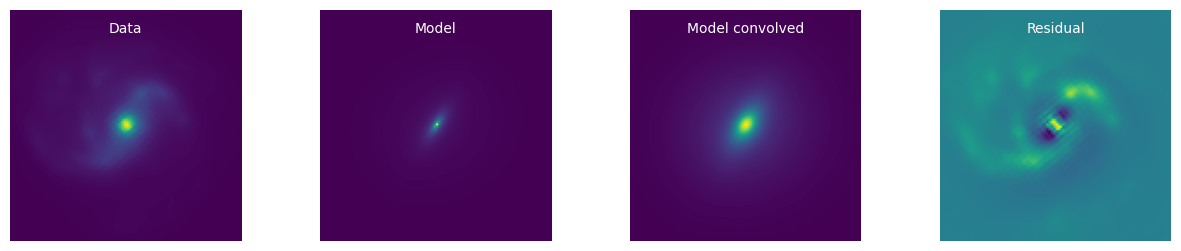

In [17]:
# Test-1
# Model = Bulge + Disk, fixed center, fixed geometry

#  common parameters
x0, y0 = center_ori
b2a = 0.887
theta = -2.705
stellar_image_cut = stellar_f277w_image_cut
stellar_err_cut = stellar_f277w_err_cut
stellar_psf = stellar_f277w_PSF_resampled
outfile = f'result_data/{name}_bulgedisk_fit_f277w.fits'


#fixed_parameters={'theta.disk': theta, 'ellip.disk':1-b2a, **fixed_center_params},
fixed_parameters={'disk.theta': theta, 'disk.ellip':1-b2a,
                  #'bulge.n':4, 'bulge.reff':5,
                  'bulge.x0':fixed_center_params['x0'], 
                  'bulge.y0':fixed_center_params['y0'], 
                  }

bulge = Sersic2D(
        amplitude=5, reff=3, n=3,
        x0=x0, y0=y0, ellip=0, theta=0,
        name='bulge')
bulge.set_bounds({
        'amplitude': (0.1, 20), 'reff': (0., 20), 'n': (0.2, 6),
    })

disk = Sersic2D(
       amplitude=0.7, reff=20, n=1,
       x0=x0, y0=y0, ellip=0, theta=0,
       name='disk')
disk.set_bounds({
        'amplitude': (0.01, 5), 'reff': (10, 50), 'n': (0.1, 4),
    })

model_galaxy = bulge + disk # disk+bulge
model_galaxy.tie('bulge.x0', 'disk.x0')
model_galaxy.tie('bulge.y0', 'disk.y0')
model_galaxy.fix(**fixed_parameters)

bestfit, *_ = fit_galaxy_with_psf(
    model_galaxy, stellar_image_cut,
    error=stellar_err_cut,
    psf=stellar_psf, #mode='de',
    return_fit_images=True, debug=True, #mask=mask1,
    fitsfile=outfile)
for item, value, value_err in zip(bestfit.keys, bestfit.best_fit, 
    bestfit.best_fit_error):
    print(f'{item}, {value:.3f}+/-{value_err:.3f}')

grid2d = Grid2D(size=stellar_image_cut.shape)
bulge.update_parameters(bestfit.parameters)
disk.update_parameters(bestfit.parameters)
bulge_model_fitted = bulge(grid2d)
disk_model_fitted = disk(grid2d)
B2T = np.sum(bulge_model_fitted)/np.sum(bulge_model_fitted + disk_model_fitted)
print('Bulge to Total (B/T)', B2T)

## Joint Fitting

{'x0': 0.2616688034253005, 'y0': 0.3398017114942945}
[122.7616688034253, 108.83980171149429]


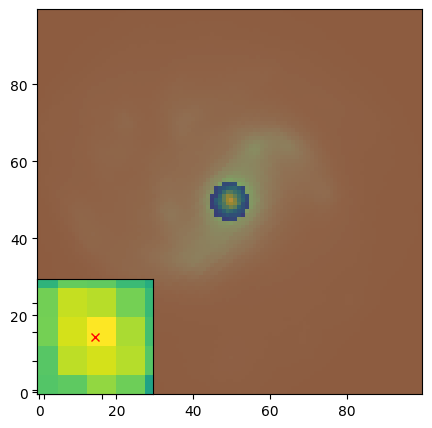

In [12]:
# manually get the center of the galaxy

from galaxyfit import fit_galaxy_center

fixed_center_params = fit_galaxy_center(stellar_f277w_image_cut, radius=5)
x0, y0 = fixed_center_params['x0'], fixed_center_params['y0']
center_ori = [x0 + cut_s[1].start + 0.5*(cut_s[1].stop-cut_s[1].start)-0.5, 
          y0 + cut_s[0].start + 0.5*(cut_s[0].stop-cut_s[0].start)-0.5]
print(fixed_center_params)
print(center_ori)

In [88]:
models_multiband = ModelList([bulge_f444w + disk_f444w, bulge_f277w + disk_f277w])


In [91]:
models_multiband.submodels

In [92]:
list(models_multiband._iter_params())

[(<modeling_utils.Sersic2D at 0x13c947520>,
  'amplitude',
  Parameter(value=5, bounds=(0.1, 20), fixed=False)),
 (<modeling_utils.Sersic2D at 0x13c947520>,
  'reff',
  Parameter(value=3, bounds=(0.0, 20), fixed=False)),
 (<modeling_utils.Sersic2D at 0x13c947520>,
  'n',
  Parameter(value=3, bounds=(0.2, 6), fixed=False)),
 (<modeling_utils.Sersic2D at 0x13c947520>,
  'x0',
  Parameter(value=122.7616688034253, bounds=(-inf, inf), fixed=False)),
 (<modeling_utils.Sersic2D at 0x13c947520>,
  'y0',
  Parameter(value=108.83980171149429, bounds=(-inf, inf), fixed=False)),
 (<modeling_utils.Sersic2D at 0x13c947520>,
  'ellip',
  Parameter(value=0, bounds=(0.001, 0.999), fixed=False)),
 (<modeling_utils.Sersic2D at 0x13c947520>,
  'theta',
  Parameter(value=0, bounds=(-1.5707963267948966, 1.5707963267948966), fixed=False)),
 (<modeling_utils.Sersic2D at 0x13d7a5870>,
  'amplitude',
  Parameter(value=5, bounds=(0.1, 20), fixed=False)),
 (<modeling_utils.Sersic2D at 0x13d7a5870>,
  'reff',
  Pa

In [14]:
disk_f444w.get_priors()

0.0

In [17]:
models_multiband.get_priors()

0.0

In [12]:
from galaxyfit import fit_galaxy_multibands
from galaxyfit import ModelList


b2a = 0.887
theta = -2.705

fixed_parameters={'disk_f444w.theta': theta, 'disk_f444w.ellip':1-b2a,
                  'bulge_f444w.ellip':0, 'bulge_f444w.theta':0,
                  'bulge_f277w.ellip':0, 'bulge_f277w.theta':0,
                  'bulge_f444w.x0':fixed_center_params['x0'], 
                  'bulge_f444w.y0':fixed_center_params['y0'], 
                  }
# 
#  F444W

# define the data
data = {
    'F444W': stellar_f444w_image_cut, 'F444W_err':stellar_f444w_err_cut, 'F444W_psf':stellar_f444w_PSF_resampled,
    'F277W': stellar_f277w_image_cut, 'F277W_err':stellar_f277w_err_cut, 'F277W_psf':stellar_f277w_PSF_resampled,
}

bulge_f444w = Sersic2D(
        amplitude=5, reff=3, n=3,
        x0=x0, y0=y0, ellip=0, theta=0,
        name='bulge_f444w')
bulge_f444w.set_bounds({
        'amplitude': (0.1, 20), 'reff': (0., 20), 'n': (0.2, 6),
    })

disk_f444w = Sersic2D(
       amplitude=0.7, reff=20, n=1,
       x0=x0, y0=y0, ellip=0, theta=0,
       name='disk_f444w')
disk_f444w.set_bounds({
        'amplitude': (0.01, 5), 'reff': (10, 50), 'n': (0.1, 4),
    })

# F277W
bulge_f277w = Sersic2D(
        amplitude=5, reff=3, n=3,
        x0=x0, y0=y0, ellip=0, theta=0,
        name='bulge_f277w')
bulge_f277w.set_bounds({
        'amplitude': (0.1, 20), 'reff': (0., 20), 'n': (0.2, 6),
    })

disk_f277w = Sersic2D(
       amplitude=0.7, reff=20, n=1,
       x0=x0, y0=y0, ellip=0, theta=0,
       name='disk_f277w')
disk_f277w.set_bounds({
        'amplitude': (0.01, 5), 'reff': (10, 50), 'n': (0.1, 4),
    })

models_multiband = ModelList([bulge_f444w + disk_f444w, bulge_f277w + disk_f277w])
models_multiband.tie('bulge_f444w.x0', 'disk_f444w.x0', 'bulge_f277w.x0', 'disk_f444w.x0')
models_multiband.tie('bulge_f444w.y0', 'disk_f444w.y0', 'bulge_f277w.y0', 'disk_f444w.y0')
models_multiband.tie('bulge_f444w.n', 'bulge_f277w.n')
models_multiband.tie('bulge_f444w.reff', 'bulge_f277w.reff')
models_multiband.tie('disk_f444w.n', 'disk_f277w.n')
models_multiband.tie('disk_f444w.reff', 'disk_f277w.reff')
models_multiband.fix(**fixed_parameters)

# 
nx, ny = stellar_f444w_image_cut.shape
grid2d = Grid2D(size=(ny, nx))
#fit_galaxy_multibands(models_multiband, grid2d, data, filters=['F444W','F277W'])

In [13]:
models_multiband.parameters

{'bulge_f444w.amplitude': 5,
 'bulge_f444w.reff': 3,
 'bulge_f444w.n': 3,
 'disk_f444w.amplitude': 0.7,
 'disk_f444w.reff': 20,
 'disk_f444w.n': 1,
 'bulge_f277w.amplitude': 5,
 'disk_f277w.amplitude': 0.7,
 'disk_f277w.x0': 0.3608621917465002,
 'disk_f277w.y0': 0.3681712224555708,
 'disk_f277w.ellip': 0,
 'disk_f277w.theta': 0}

In [14]:
filters = ['F444W', 'F356W', 'F277W']
wavelengths = {'F444W': 44000, 'F356W':25600, 'F277W': 27700}

def build_one_band():
    bulge = Sersic2D(amplitude=1, reff=5, n=2.5, x0=50, y0=50, ellip=0.2, theta=0.5, name='bulge')
    disk  = Sersic2D(amplitude=1, reff=20, n=1.0, x0=50, y0=50, ellip=0.5, theta=0.5, name='disk')
    return bulge + disk

joint_model = ModelList.from_template(build_one_band, filters)
# geometry (reff, n, x0, y0, ellip, theta) automatically tied across all 3 filters
# amplitude remains free & independent per filter (safely disambiguated:
#   'bulge_F444W.amplitude', 'bulge_F277W.amplitude', 'bulge_F150W.amplitude')

In [16]:
from galaxyfit import FixedDustScreen

sigma_dust_map = np.ones_like(stellar_f444w_image_cut)

dust_screens = {
    filt: FixedDustScreen(dust_map=sigma_dust_map, name=f'dust_{filt}')
    for filt in filters
}

kappa0, beta = FixedDustScreen.attach_power_law_kappa(
    dust_screens, wavelengths, lambda0=5500, beta0=1.3
)

# Build one full model per filter, attenuated by that filter's dust screen
joint_model_dustscreen = ModelList(
    [ joint_model * dust_screens[f] for f in filters ],
    filters=filters,
)
# free params now include shared: kappa0, beta (2 numbers control ALL bands' dust)
# rather than one independent kappa per filter

In [26]:
joint_model_dustscreen.models

[(<galaxyfit.ModelList object at 0x15e84a380> * <galaxyfit.FixedDustScreen object at 0x15eb114b0>),
 (<galaxyfit.ModelList object at 0x15e84a380> * <galaxyfit.FixedDustScreen object at 0x15eae2200>),
 (<galaxyfit.ModelList object at 0x15e84a380> * <galaxyfit.FixedDustScreen object at 0x15eb42500>)]

In [35]:
joint_model_dustscreen.parameters

{'bulge_F444W_F277W.amplitude': 1,
 'bulge_F444W_F277W.reff': 5,
 'bulge_F444W_F277W.n': 2.5,
 'bulge_F444W_F277W.x0': 50,
 'bulge_F444W_F277W.y0': 50,
 'bulge_F444W_F277W.ellip': 0.2,
 'bulge_F444W_F277W.theta': 0.5,
 'disk_F444W_F277W.amplitude': 1,
 'disk_F444W_F277W.reff': 20,
 'disk_F444W_F277W.n': 1.0,
 'disk_F444W_F277W.x0': 50,
 'disk_F444W_F277W.y0': 50,
 'disk_F444W_F277W.ellip': 0.5,
 'disk_F444W_F277W.theta': 0.5,
 'bulge_F356W_F277W.amplitude': 1,
 'disk_F356W_F277W.amplitude': 1,
 'bulge_F277W_F277W.amplitude': 1,
 'disk_F277W_F277W.amplitude': 1,
 'dust_F444W.scale': 1.0,
 'dust_F356W.scale': 1.0,
 'dust_F277W.scale': 1.0}

In [ ]:
filters = ['F444W', 'F277W', 'F150W']

def build_one_band():
    bulge = Sersic2D(amplitude=1, reff=5, n=2.5, x0=50, y0=50, ellip=0.2, theta=0.5, name='bulge')
    disk  = Sersic2D(amplitude=1, reff=20, n=1.0, x0=50, y0=50, ellip=0.5, theta=0.5, name='disk')
    return bulge + disk

models = ModelList.from_template(build_one_band, filters)


dust = ExponentialDustScreen(tau0=0.4, h_dust=15, name='dust')
observed_bulge_F444W = bulge_intrinsic_F444W * dust   # elementwise transmission map

dust.tau0_F277W = DerivedParameter(lambda tau0_ref: tau0_ref * (27700/44000)**(-0.7), dust.tau0)

# Others

In [19]:
#  common parameters
x0, y0 = center_ori
b2a = 0.887
theta = -2.705
stellar_image_cut = stellar_f444w_image_cut
stellar_err_cut = stellar_f444w_err_cut
stellar_psf = stellar_f444w_PSF_resampled
outfile = f'result_data/{name}_bulgediskfit_f444w.fits'


#fixed_parameters={'theta_disk': theta, 'ellip_disk':1-b2a, **fixed_center_params},
fixed_parameters={'theta_disk': theta, 'ellip_disk':1-b2a,
                  'bulge_n':4, 'bulge_reff':5, **fixed_center_params}

x0 = fixed_parameters['x0']#1.618155
y0 = fixed_parameters['y0']#-0.348215

#center_x = Parameter(x0, bounds=[-5, 5], name='center_x')
#center_y = Parameter(y0, bounds=[-5, 5], name='center_y')

# bulge component
sersic_bulge = Sersic2D(
    amplitude = Parameter(5, bounds=[0.1,20]),
    reff = Parameter(3, bounds=[0, 20]),
    n = Parameter(3, bounds=[0.2, 5]), 
    x0 = fixed_parameters['x0'], #Parameter(0, bounds=[-5, 5]), 
    y0 = fixed_center_params['y0'], #Parameter(0, bounds=[-5, 5]),
    ellip = fixed_parameters['ellip_disk'], #Parameter(fixed_parameters['ellip_disk'], bounds=[0, 1]) #,
    theta = fixed_parameters['theta_disk'], #Parameter(fixed_parameters['theta_disk'], bounds=[-0.5*np.pi, 0.5*np.pi]), #,
    name='bulge')

sersic_disk = Sersic2D(
    amplitude = Parameter(0.7, bounds=[0.01,5]),
    reff = Parameter(20, bounds=[10, 50]),
    n = Parameter(1, bounds=[0.1, 4]),
    x0 = fixed_parameters['x0'], #center_x,#Parameter(0, bounds=[-10, 10]), 
    y0 = fixed_parameters['y0'],#Parameter(0, bounds=[-10, 10]),
    ellip = fixed_parameters['ellip_disk'],#Parameter(0.1, bounds=[0, 1]),
    theta = fixed_parameters['theta_disk'],#Parameter(theta0, bounds=[-0.5*np.pi, 0.5*np.pi]),
    name='disk')

model_galaxy = sersic_bulge + sersic_disk # disk+bulge
model_galaxy.tie('bulge.x0', 'disk.x0')
model_galaxy.tie('bulge.y0', 'disk.y0')
model_galaxy.fix('bulge.ellip', 'bulge.theta')
model_galaxy.fix('disk.ellip', 'disk.theta')


bestfit, *_ = fit_galaxy_with_psf(
    model_galaxy, stellar_image_cut,
    error=stellar_err_cut,
    psf=stellar_psf, #mode='de',
    return_fit_images=True, debug=True, #mask=mask1,
    #fitsfile=f'result_data/test_bulge_disk2_witherror.fits')
    fitsfile=outfile)
for item, value in bestfit.items():
    print(f'{item}, {value[0]:.3f}+/-{value[1]:.3f}')

grid2d = Grid2D(size=stellar_image_cut.shape)
sersic_bulge.update_parameters({**bestfit,**fixed_parameters})
sersic_disk.update_parameters({**bestfit,**fixed_parameters})
bulge_model_fitted = sersic_bulge.model_on_grid(grid2d)
disk_model_fitted = sersic_disk.model_on_grid(grid2d)
B2T = np.sum(bulge_model_fitted)/np.sum(bulge_model_fitted + disk_model_fitted)
print('Bulge to total', B2T)

KeyError: "Cannot resolve parameter path 'disk.x0'"

{'x0': 0.36959115821530336, 'y0': 0.301327086567843}


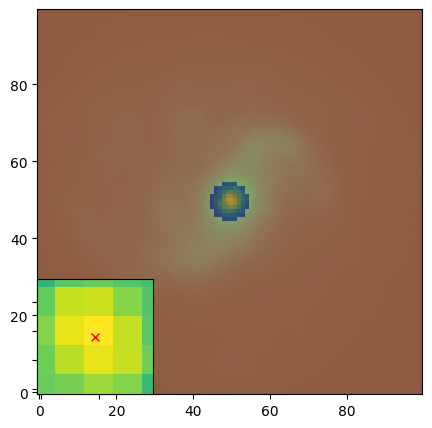

In [59]:
# F356W

fixed_center_params = fit_galaxy_center(stellar_f356w_image_cut, radius=5)
x0, y0 = fixed_center_params['x0'], fixed_center_params['y0']
center_ori = [x0 + cut_s[1].start + 0.5*(cut_s[1].stop-cut_s[1].start)-0.5, 
          y0 + cut_s[0].start + 0.5*(cut_s[0].stop-cut_s[0].start)-0.5]
print(fixed_center_params)


Initial guess: {'bulge.amplitude': 5, 'bulge.reff': 3, 'bulge.n': 3, 'disk.amplitude': 0.7, 'disk.reff': 20, 'disk.n': 1}


/Users/jhchen/work/projects/code_snippets/utils/model_utils.py:515: RuntimeWarning: divide by zero encountered in divide
  z = ((x_maj / self.reff.value) ** expon + (x_min / b) ** expon) ** inv_expon


Parameter: ['bulge.amplitude', 'bulge.reff', 'bulge.n', 'disk.amplitude', 'disk.reff', 'disk.n']
first best_fit: [ 9.96746942  2.01795628  0.76049329  0.48012645 20.81328886  1.05614937]
data_size: 10000; first_cost 12003661.89280868;
Reduced chi2 of first minimize: 1201.0868413856995
`ftol` termination condition is satisfied.
Function evaluations 9, initial cost 1.1994e+07, final cost 1.1994e+07, first-order optimality 1.34e+03.
data_size: 10000; cost: 23988107.29048311
Reduced chi2 of leastsq: 2400.2508795760564
second cost: 12003661.908783497
Reduced chi2 of first minimize (mine): 1201.0868429841403
Error scaled: [10.99602881  1.12602955  3.69974356  0.07196795  1.57785727  0.29651219]
Error pcov: [0.22444377 0.02298378 0.07551675 0.00146896 0.03220619 0.00605221]
bulge.amplitude, 9.967+/-10.996
bulge.reff, 2.018+/-1.126
bulge.n, 0.760+/-3.700
disk.amplitude, 0.480+/-0.072
disk.reff, 20.813+/-1.578
disk.n, 1.056+/-0.297
Bulge to total 0.1530113735209112


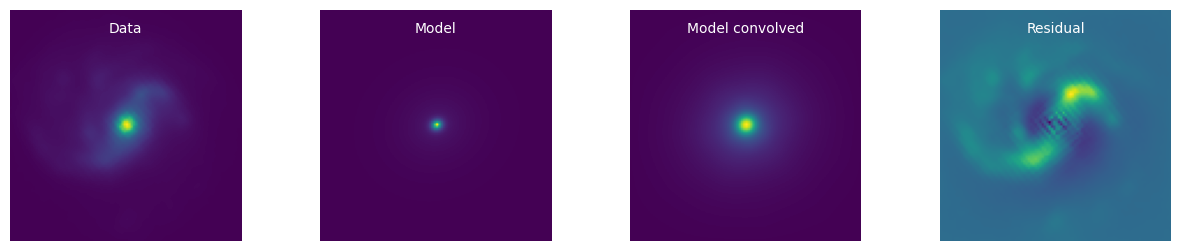

In [60]:
#  common parameters
x0, y0 = center_ori
b2a = 0.887
theta = -2.705
stellar_image_cut = stellar_f356w_image_cut
stellar_err_cut = stellar_f356w_err_cut
stellar_psf = stellar_f356w_PSF_resampled
outfile = f'result_data/{name}_bulgediskfit_f356w.fits'


#fixed_parameters={'theta_disk': theta, 'ellip_disk':1-b2a, **fixed_center_params},
fixed_parameters={'theta_disk': theta, 'ellip_disk':1-b2a,
                  'bulge_n':4, 'bulge_reff':5, **fixed_center_params}

x0 = fixed_parameters['x0']#1.618155
y0 = fixed_parameters['y0']#-0.348215

#center_x = Parameter(x0, limits=[-5, 5], name='center_x')
#center_y = Parameter(y0, limits=[-5, 5], name='center_y')

# bulge component
sersic_bulge = Sersic2D(
    amplitude = Parameter(5, limits=[0.1,20]),
    reff = Parameter(3, limits=[0, 20]),
    n = Parameter(3, limits=[0.2, 5]), 
    x0 = fixed_parameters['x0'], #Parameter(0, limits=[-5, 5]), 
    y0 = fixed_center_params['y0'], #Parameter(0, limits=[-5, 5]),
    ellip = fixed_parameters['ellip_disk'], #Parameter(fixed_parameters['ellip_disk'], limits=[0, 1]) #,
    theta = fixed_parameters['theta_disk'], #Parameter(fixed_parameters['theta_disk'], limits=[-0.5*np.pi, 0.5*np.pi]), #,
    name='bulge')

sersic_disk = Sersic2D(
    amplitude = Parameter(0.7, limits=[0.01,5]),
    reff = Parameter(20, limits=[10, 50]),
    n = Parameter(1, limits=[0.1, 4]),
    x0 = fixed_parameters['x0'], #center_x,#Parameter(0, limits=[-10, 10]), 
    y0 = fixed_parameters['y0'],#Parameter(0, limits=[-10, 10]),
    ellip = fixed_parameters['ellip_disk'],#Parameter(0.1, limits=[0, 1]),
    theta = fixed_parameters['theta_disk'],#Parameter(theta0, limits=[-0.5*np.pi, 0.5*np.pi]),
    name='disk')

models2 = Models([sersic_bulge, sersic_disk]) # disk+bulge
bestfit, *_ = fit_galaxy_with_psf(
    models2, stellar_image_cut,
    error=stellar_err_cut,
    psf=stellar_psf, #mode='de',
    return_fit_images=True, debug=True, #mask=mask1,
    #fitsfile=f'result_data/test_bulge_disk2_witherror.fits')
    fitsfile=outfile)
for item, value in bestfit.items():
    print(f'{item}, {value[0]:.3f}+/-{value[1]:.3f}')

grid2d = Grid2D(size=stellar_image_cut.shape)
sersic_bulge.update_parameters({**bestfit,**fixed_parameters})
sersic_disk.update_parameters({**bestfit,**fixed_parameters})
bulge_model_fitted = sersic_bulge.model_on_grid(grid2d)
disk_model_fitted = sersic_disk.model_on_grid(grid2d)
B2T = np.sum(bulge_model_fitted)/np.sum(bulge_model_fitted + disk_model_fitted)
print('Bulge to total', B2T)

{'x0': 0.2623317471484211, 'y0': 0.3378059188004383}


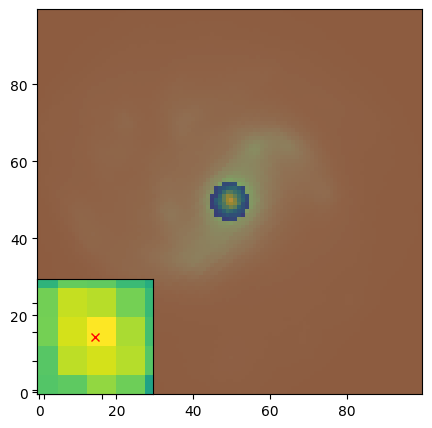

In [56]:
# F277W

fixed_center_params = fit_galaxy_center(stellar_f277w_image_cut, radius=5)
x0, y0 = fixed_center_params['x0'], fixed_center_params['y0']
center_ori = [x0 + cut_s[1].start + 0.5*(cut_s[1].stop-cut_s[1].start)-0.5, 
          y0 + cut_s[0].start + 0.5*(cut_s[0].stop-cut_s[0].start)-0.5]
print(fixed_center_params)


Initial guess: {'bulge.amplitude': 5, 'bulge.reff': 3, 'bulge.n': 3, 'disk.amplitude': 0.7, 'disk.reff': 20, 'disk.n': 1}


/Users/jhchen/work/projects/code_snippets/utils/model_utils.py:515: RuntimeWarning: divide by zero encountered in divide
  z = ((x_maj / self.reff.value) ** expon + (x_min / b) ** expon) ** inv_expon


Parameter: ['bulge.amplitude', 'bulge.reff', 'bulge.n', 'disk.amplitude', 'disk.reff', 'disk.n']
first best_fit: [ 7.16382048  1.99372849  1.02165927  0.39835873 21.34841466  1.06099477]
data_size: 10000; first_cost 9459509.79096403;
Reduced chi2 of first minimize: 946.5188904306614
`ftol` termination condition is satisfied.
Function evaluations 8, initial cost 9.4499e+06, final cost 9.4499e+06, first-order optimality 1.70e+03.
data_size: 10000; cost: 18899879.970872737
Reduced chi2 of leastsq: 1891.1226706896875
second cost: 9459509.797142947
Reduced chi2 of first minimize (mine): 946.518891048924
Error scaled: [6.56786333 0.74531497 2.50165098 0.05533463 1.47028219 0.27206553]
Error pcov: [0.15103036 0.01713878 0.05752636 0.00127244 0.03380966 0.00625624]
bulge.amplitude, 7.164+/-6.568
bulge.reff, 1.994+/-0.745
bulge.n, 1.022+/-2.502
disk.amplitude, 0.398+/-0.055
disk.reff, 21.348+/-1.470
disk.n, 1.061+/-0.272
Bulge to total 0.14187565044338504


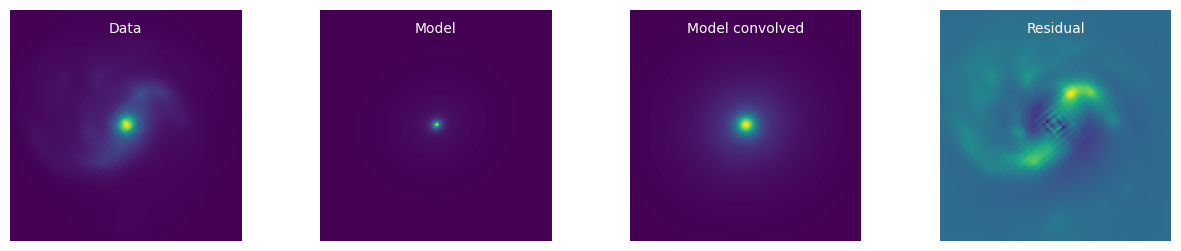

In [ ]:
#  common parameters
x0, y0 = center_ori
b2a = 0.887
theta = -2.705
stellar_image_cut = stellar_f277w_image_cut
stellar_err_cut = stellar_f277w_err_cut
stellar_psf = stellar_f277w_PSF_resampled
outfile = f'result_data/{name}_bulgediskfit_f277w.fits'


#fixed_parameters={'theta_disk': theta, 'ellip_disk':1-b2a, **fixed_center_params},
fixed_parameters={'theta_disk': theta, 'ellip_disk':1-b2a,
                  'bulge_n':4, 'bulge_reff':5, **fixed_center_params}

x0 = fixed_parameters['x0']#1.618155
y0 = fixed_parameters['y0']#-0.348215

#center_x = Parameter(x0, limits=[-5, 5], name='center_x')
#center_y = Parameter(y0, limits=[-5, 5], name='center_y')

# bulge component
sersic_bulge = Sersic2D(
    amplitude = Parameter(5, limits=[0.1,20]),
    reff = Parameter(3, limits=[0, 20]),
    n = Parameter(3, limits=[0.2, 5]), 
    x0 = fixed_parameters['x0'], #Parameter(0, limits=[-5, 5]), 
    y0 = fixed_center_params['y0'], #Parameter(0, limits=[-5, 5]),
    ellip = fixed_parameters['ellip_disk'], #Parameter(fixed_parameters['ellip_disk'], limits=[0, 1]) #,
    theta = fixed_parameters['theta_disk'], #Parameter(fixed_parameters['theta_disk'], limits=[-0.5*np.pi, 0.5*np.pi]), #,
    name='bulge')

sersic_disk = Sersic2D(
    amplitude = Parameter(0.7, limits=[0.01,5]),
    reff = Parameter(20, limits=[10, 50]),
    n = Parameter(1, limits=[0.1, 4]),
    x0 = fixed_parameters['x0'], #center_x,#Parameter(0, limits=[-10, 10]), 
    y0 = fixed_parameters['y0'],#Parameter(0, limits=[-10, 10]),
    ellip = fixed_parameters['ellip_disk'],#Parameter(0.1, limits=[0, 1]),
    theta = fixed_parameters['theta_disk'],#Parameter(theta0, limits=[-0.5*np.pi, 0.5*np.pi]),
    name='disk')

models2 = Models([sersic_bulge, sersic_disk]) # disk+bulge
bestfit, *_ = fit_galaxy_with_psf(
    models2, stellar_image_cut,
    error=stellar_err_cut,
    psf=stellar_psf, #mode='de',
    return_fit_images=True, debug=True, #mask=mask1,
    #fitsfile=f'result_data/test_bulge_disk2_witherror.fits')
    fitsfile=outfile)
for item, value in bestfit.items():
    print(f'{item}, {value[0]:.3f}+/-{value[1]:.3f}')

grid2d = Grid2D(size=stellar_image_cut.shape)
sersic_bulge.update_parameters({**bestfit,**fixed_parameters})
sersic_disk.update_parameters({**bestfit,**fixed_parameters})
bulge_model_fitted = sersic_bulge.model_on_grid(grid2d)
disk_model_fitted = sersic_disk.model_on_grid(grid2d)
B2T = np.sum(bulge_model_fitted)/np.sum(bulge_model_fitted + disk_model_fitted)
print('Bulge to total', B2T)

In [18]:
# fit multiple bands together

from galaxyfit import fit_galaxy_multibands

#  common parameters
x0, y0 = center_ori
b2a = 0.887
theta = -2.705
stellar_image_cut = stellar_f444w_image_cut

#fixed_parameters={'theta_disk': theta, 'ellip_disk':1-b2a, **fixed_center_params},
fixed_parameters={'theta_disk': theta, 'ellip_disk':1-b2a,
                  'bulge_n':4, 'bulge_reff':5, **fixed_center_params}

x0 = fixed_parameters['x0']#1.618155
y0 = fixed_parameters['y0']#-0.348215

#center_x = Parameter(x0, limits=[-5, 5], name='center_x')
#center_y = Parameter(y0, limits=[-5, 5], name='center_y')

n_buge = Parameter(3, limits=[0.2, 5])
n_disk = Parameter(1, limits=[0.1, 4])

# bulge component
sersic_bulge = Sersic2D(
    amplitude = Parameter(5, limits=[0.1,20]),
    reff = Parameter(3, limits=[0, 20]),
    n = Parameter(3, limits=[0.2, 5]), 
    x0 = fixed_parameters['x0'], #Parameter(0, limits=[-5, 5]), 
    y0 = fixed_center_params['y0'], #Parameter(0, limits=[-5, 5]),
    ellip = fixed_parameters['ellip_disk'], #Parameter(fixed_parameters['ellip_disk'], limits=[0, 1]) #,
    theta = fixed_parameters['theta_disk'], #Parameter(fixed_parameters['theta_disk'], limits=[-0.5*np.pi, 0.5*np.pi]), #,
    name='bulge')

sersic_disk = Sersic2D(
    amplitude = Parameter(0.7, limits=[0.01,5]),
    reff = Parameter(20, limits=[10, 50]),
    n = Parameter(1, limits=[0.1, 4]),
    x0 = fixed_parameters['x0'], #center_x,#Parameter(0, limits=[-10, 10]), 
    y0 = fixed_parameters['y0'],#Parameter(0, limits=[-10, 10]),
    ellip = fixed_parameters['ellip_disk'],#Parameter(0.1, limits=[0, 1]),
    theta = fixed_parameters['theta_disk'],#Parameter(theta0, limits=[-0.5*np.pi, 0.5*np.pi]),
    name='disk')

grid2d = Grid2D(size=stellar_image_cut.shape)
models2 = Models([sersic_bulge, sersic_disk]) # disk+bulge
bestfit, *_ = fit_galaxy_multibands(
    models=models2, 
    data=[stellar_f444w_image_cut, stellar_f356w_image_cut],
    grid2d=grid2d,
    error=[stellar_f444w_err_cut, stellar_f356w_err_cut],
    psf=[stellar_f444w_PSF_resampled, stellar_f356w_PSF_resampled],
    return_fit_images=True, debug=True, #mask=mask1,
    fitsfile=outfile)
for item, value in bestfit.items():
    print(f'{item}, {value[0]:.3f}+/-{value[1]:.3f}')


sersic_bulge.update_parameters({**bestfit,**fixed_parameters})
sersic_disk.update_parameters({**bestfit,**fixed_parameters})
bulge_model_fitted = sersic_bulge.model_on_grid(grid2d)
disk_model_fitted = sersic_disk.model_on_grid(grid2d)
B2T = np.sum(bulge_model_fitted)/np.sum(bulge_model_fitted + disk_model_fitted)
print('Bulge to total', B2T)

TypeError: Parameter.__init__() got an unexpected keyword argument 'limits'